# Student Performance Prediction in Bangladesh

This notebook demonstrates a complete machine learning pipeline to predict HSC results based on student demographics, family background, and previous academic performance (SSC results).

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler

from sklearn.pipeline import Pipeline


from sklearn.linear_model import LinearRegression, SGDRegressor

from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

In [122]:
url = "https://raw.githubusercontent.com/MuktadirHQ/AIML-Expert-With-Phitron/refs/heads/main/Machine%20Learning/WEEK%20-%2003.%20Intro%20to%20ML%2C%20Linear%20and%20Logistic%20Regression/Module_12.%20Multiple%20Linear%20Regression%20with%20Scikit%20Learn/__Resources/bangladesh_student_performance_updated.csv"

In [123]:
df = pd.read_csv(url)
df.head()

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
0,29/04/2018,M,18.0,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672.0,4,4.22,3.72
1,29/04/2018,F,19.0,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085.0,5,3.47,2.62
2,29/04/2018,F,19.0,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891.0,3,3.32,2.56
3,29/04/2018,F,19.0,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600.0,2,4.57,4.17
4,29/04/2018,M,17.0,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458.0,2,4.50,3.94


In [124]:
df.shape

(2018, 16)

In [125]:
df.sample(10)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
250,29/04/2018,M,19.0,Rural,GT3,Together,2,3,Teacher,Services,No,No,57920.0,2,3.02,2.94
101,29/04/2018,F,19.0,Rural,GT3,Together,2,1,Teacher,Business,No,Yes,50405.0,3,4.18,3.33
1885,29/04/2018,M,19.0,Urban,GT3,Together,2,2,Other,Business,No,No,118835.0,2,4.49,3.85
744,29/04/2018,M,17.0,Rural,GT3,Together,3,2,At_home,Health,Yes,No,49680.0,3,4.32,3.53
212,29/04/2018,F,19.0,Urban,GT3,Together,3,4,Health,Health,No,No,114247.0,4,2.37,2.08
149,29/04/2018,M,19.0,Rural,GT3,Together,4,1,At_home,Farmer,No,No,71028.0,3,3.75,3.19
2009,29/04/2018,M,19.0,Rural,LE3,Together,0,2,Health,Business,No,No,55365.0,3,4.14,3.53
1367,29/04/2018,F,18.0,Rural,LE3,Together,1,2,Health,Business,No,No,53434.0,4,3.56,3.00
672,29/04/2018,M,19.0,Rural,GT3,Together,3,0,Teacher,Health,No,No,43896.0,4,3.44,2.88
1256,29/04/2018,M,17.0,Rural,LE3,Together,4,2,Teacher,Business,No,No,87233.0,3,4.26,3.72


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           1983 non-null   float64
 3   address       1983 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         1983 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   1983 non-null   float64
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(4), int64(3), object(9)
memory usage: 252.4+ KB


In [127]:
df['time_friends'].unique()
df['M_Edu'].unique()
df['famsize'].unique()

array(['GT3', 'LE3'], dtype=object)

In [128]:
df.isnull().sum()

,0
date,0
gender,0
age,35
address,35
famsize,0
Pstatus,0
M_Edu,0
F_Edu,0
M_Job,35
F_Job,0


In [129]:
df.describe()

,age,M_Edu,F_Edu,tuition_fee,time_friends,ssc_result,hsc_result
count,1983.000000,2018.000000,2018.000000,1983.000000,2018.00000,2018.000000,2018.000000
mean,17.980837,1.871160,2.174430,73045.274332,3.05996,3.788087,3.199177
std,0.825695,1.194206,1.252979,24102.016020,1.43919,0.622376,0.604526
min,17.000000,0.000000,0.000000,25102.000000,1.00000,2.000000,2.000000
25%,17.000000,1.000000,1.000000,53639.500000,2.00000,3.360000,2.780000
50%,18.000000,2.000000,2.000000,71343.000000,3.00000,3.770000,3.160000
75%,19.000000,3.000000,3.000000,91185.000000,4.00000,4.230000,3.580000
max,19.000000,4.000000,4.000000,129168.000000,5.00000,5.000000,5.000000


In [130]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

# EDA


Text(0.5, 0.98, 'Distribution of Numerical Features')

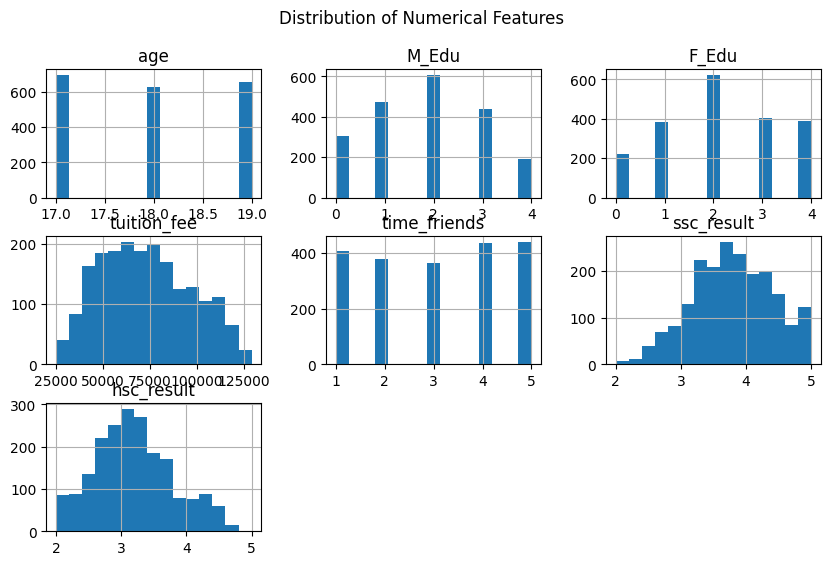

In [131]:
df.hist(bins=15, figsize=(10, 6))
plt.suptitle("Distribution of Numerical Features")

In [132]:
numerical_cols = ['age', 'tuition_fee', 'ssc_result', 'hsc_result']
df[numerical_cols].corr()

,age,tuition_fee,ssc_result,hsc_result
age,1.000000,0.001015,-0.013061,-0.012592
tuition_fee,0.001015,1.000000,0.018385,0.041205
ssc_result,-0.013061,0.018385,1.000000,0.950178
hsc_result,-0.012592,0.041205,0.950178,1.000000


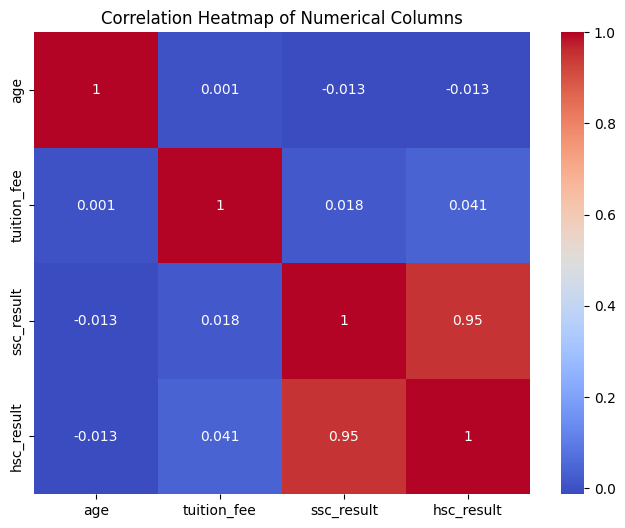

In [133]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap of Numerical Columns")
plt.show()

<Axes: xlabel='ssc_result'>

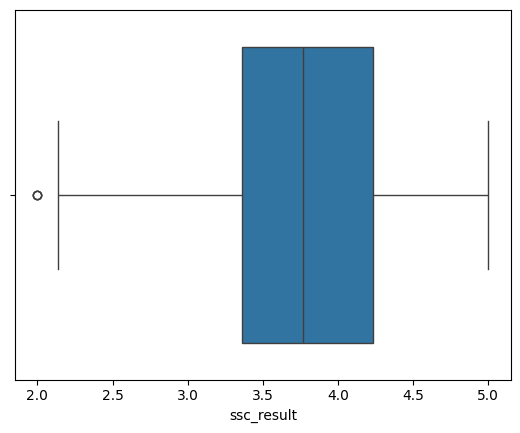

In [134]:
sns.boxplot(df, x='ssc_result')

# Preprocessing

In [135]:
nominal_cat = ['gender', 'address', 'famsize', 'Pstatus', 'relationship', 'smoker', 'M_Job', 'F_Job']
# ordinal_cat = ['M_Edu', 'F_Edu', 'time_friends']

# m_edu_order = ['0', '1', '2', '3', '4']
# f_edu_order = ['0', '1', '2', '3', '4']
# time_friends_order = ['5', '4', '3', '2', '1']

numerical_cols = ['age', 'tuition_fee', 'ssc_result']

##### Neumetical Transformers

In [136]:
numerical_transformers = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]
)
numerical_transformers

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])

##### Nominal Transformers

In [137]:
nominal_transformers = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ]
)
nominal_transformers

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

##### Ordinal Transformers

In [138]:
# ordinal_transformers = Pipeline(
#     steps = [
#         ('imputer', SimpleImputer(strategy='most_frequent')),
#         ('encoder', OrdinalEncoder(categories=[m_edu_order, f_edu_order, time_friends_order])),
#         ('scaling', MinMaxScaler())
#     ]
# )
# ordinal_transformers

In [139]:
X = df.drop(['date', 'hsc_result'], axis=1)
y = df['hsc_result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [140]:
preprocessor = ColumnTransformer(
    transformers=[
        ('neumerical', numerical_transformers, numerical_cols),
        ('nominal', nominal_transformers, nominal_cat),
        # ('ordinal', ordinal_transformers, ordinal_cat)
    ],

    remainder='passthrough'
)

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('neumerical',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'tuition_fee', 'ssc_result']),
                                ('nominal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'address', 'famsize', 'Pstatus',
                                  'relationship', 'smoker', 'M_Job',
                                  'F_Job'])])

# LinearRegression Pipeline

In [141]:
lr_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

lr_pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('neumerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'address',
                                                   'famsize', 'Pstatus',
                                                   'relationship', 'smoker',
                                                   'M_Job', 'F_Job'])])),
                ('model', LinearRegression())])

In [143]:
X_test

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
1556,F,17.0,Rural,GT3,Together,1,1,At_home,Teacher,Yes,No,52743.0,1,3.88
526,M,19.0,Rural,GT3,Together,4,3,At_home,Business,No,No,58678.0,5,4.36
393,F,18.0,Urban,GT3,Together,2,1,Services,Services,No,No,115832.0,3,4.47
1789,M,17.0,Urban,GT3,Together,2,3,Health,Teacher,No,Yes,112781.0,1,4.43
433,M,19.0,Rural,LE3,Together,1,0,Teacher,Farmer,No,Yes,52481.0,4,4.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,M,17.0,Rural,GT3,Apart,1,4,Health,Teacher,No,No,60345.0,4,3.47
693,M,19.0,Urban,GT3,Together,1,2,Health,Business,No,No,85346.0,4,2.96
1494,F,18.0,Rural,LE3,Together,1,4,Teacher,Teacher,No,No,30638.0,1,3.76
921,M,NaN,Urban,GT3,Together,0,1,Teacher,Teacher,No,No,76804.0,2,4.18


In [142]:
lr_pipe.predict(X_test)

array([3.22566531, 3.75147018, 3.83019613, 4.00664186, 3.90886468,
       3.33301608, 3.9843285 , 2.54037997, 1.97886626, 3.27239028,
       3.67549746, 2.91990239, 3.23829796, 4.27797546, 3.03907632,
       2.67683989, 3.71729372, 3.45240833, 2.8064922 , 2.96057683,
       2.82062305, 3.20485147, 2.99957398, 3.21864928, 1.89881831,
       2.58370593, 3.18675035, 3.82959511, 3.08845188, 3.94801852,
       2.39854271, 3.94466671, 4.31696495, 2.56460476, 3.19397834,
       3.26413536, 2.75935124, 3.65848872, 2.48692797, 2.60907848,
       3.07614707, 2.97405288, 3.73760615, 2.76965129, 2.17795697,
       3.0682365 , 2.62107646, 2.60926091, 4.03558054, 3.26099047,
       3.07457897, 3.45268988, 4.23316558, 3.63562822, 3.07047904,
       3.19897028, 3.29199946, 2.67475419, 3.81647227, 2.67135675,
       3.00589862, 2.76737407, 2.49028194, 4.43360442, 2.5597574 ,
       3.21127693, 3.96661533, 2.67087186, 3.03353973, 3.22560591,
       3.03057043, 2.72163419, 2.61374344, 3.63605177, 3.07885

# SGDRegressor Pipeline

In [144]:
sgd_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', SGDRegressor())
    ]
)

sgd_pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('neumerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'address',
                                                   'famsize', 'Pstatus',
                                                   'relationship', 'smoker',
                                                   'M_Job', 'F_Job'])])),
                ('model', SGDRegressor())])

In [145]:
sgd_pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('neumerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'address',
                                                   'famsize', 'Pstatus',
                                                   'relationship', 'smoker',
                                                   'M_Job', 'F_Job'])])),
                ('model', SGDRegressor())])

In [146]:
sgd_pipe.predict(X_test)

array([3.22304814, 3.78444631, 3.84140047, 3.95063644, 3.85320489,
       3.35532671, 3.95595481, 2.52237489, 1.97451529, 3.29581117,
       3.68634926, 2.93181846, 3.24940741, 4.29157351, 3.06255187,
       2.64664362, 3.72239892, 3.4013134 , 2.82674345, 2.94776301,
       2.83701732, 3.22491679, 2.97084727, 3.2095516 , 1.9170518 ,
       2.51213949, 3.21827072, 3.83729637, 3.05671947, 3.96647377,
       2.41600105, 3.96431574, 4.28896018, 2.5922143 , 3.21457327,
       3.2899397 , 2.77855477, 3.68274912, 2.50501387, 2.62017888,
       3.100409  , 2.99126635, 3.74761288, 2.78575296, 2.14299426,
       3.09401468, 2.65500068, 2.60997071, 3.99541652, 3.24676628,
       3.07171687, 3.46849212, 4.21333771, 3.63161606, 3.06361557,
       3.16843895, 3.31481969, 2.68019467, 3.82841125, 2.61262752,
       3.03772789, 2.77615067, 2.49671603, 4.44573983, 2.58454019,
       3.226719  , 3.92614014, 2.68929623, 3.0478268 , 3.20542188,
       3.03940343, 2.75007289, 2.62798624, 3.66320513, 3.08752

# Metrics


##### Linear


In [153]:
y_pred = lr_pipe.predict(X_test)

MSE = mean_squared_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)
R2Score = r2_score(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)


print(f'MSE : {round(MSE, 4)}')
print(f'RMSE : {round(RMSE, 4)}')
print(f'R2Score : {round(R2Score, 4)}')
print(f'MAE : {round(MAE, 4)}')

MSE : 0.0203
RMSE : 0.1425
R2Score : 0.9459
MAE : 0.1114


##### SGD

In [154]:
y_pred = sgd_pipe.predict(X_test)

MSE = mean_squared_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)
R2Score = r2_score(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)


print(f'MSE : {round(MSE, 4)}')
print(f'RMSE : {round(RMSE, 4)}')
print(f'R2Score : {round(R2Score, 4)}')
print(f'MAE : {round(MAE, 4)}')

MSE : 0.0202
RMSE : 0.1423
R2Score : 0.946
MAE : 0.112
